# EfficientNet-B0 U-Net Amodal Training with Enhanced Augmentation v3 (3000 images)

**Amodal Segmentation**: Multi-label approach where each mask (eyelid, iris, pupil) is predicted independently, allowing overlaps.

**Model**: `segmentation_models_pytorch` (smp) U-Net with EfficientNet-B0 encoder (ImageNet pretrained)

## Key Differences from SegFormer-B3 version
- Uses `smp.Unet(encoder_name="efficientnet-b0")` instead of SegFormer-B3
- Standard torchvision normalization instead of SegformerImageProcessor
- Higher learning rate (1e-4) suitable for smp models
- Larger batch size (16) due to smaller model size
- Output is directly (B, C, H, W) logits — no need for upsampling

## Augmentation Pipeline (same as v3)

### 1. Geometric (unchanged)
- RandomResizedCrop (scale 80%-100%)
- Rotation (±180°)

### 2. Color/Exposure (unchanged from v2)
- RandomBrightnessContrast (±25%)
- RandomGamma (70-140%)

### 3. Blur/Low-Quality (v3 ENHANCED - Option B)
| Augmentation | v2 | v3 |
|--------------|----|----|
| Blur kernel | 5-11 | **7-15** |
| MotionBlur kernel | 5-15 | **7-21** |
| GaussianBlur | kernel 5-11, σ 1.0-3.0 | **kernel 7-15, σ 1.5-5.0** |
| Downscale (standard) | 0.25-0.5 (2x-4x) | **0.15-0.35 (3x-7x)** |
| Downscale (extreme) | - | **NEW: 0.0625-0.125 (8x-16x)** |
| Defocus | - | **NEW: radius 5-10** |
| ZoomBlur | - | **NEW: max_factor 1.1-1.3** |
| **Probability** | 0.5 | **0.6** |

### 4. JPEG Compression (unchanged from v2)
- ImageCompression (quality 20-70)

### 5. Noise (unchanged from v2)
- GaussNoise (σ=5-25)
- ISONoise (camera ISO simulation)

## 3 Masks
| Channel | Name | Description |
|---------|------|-------------|
| 0 | eyelid | Full eyelid region (conjunctiva + visible iris/pupil) |
| 1 | iris | Full iris ellipse |
| 2 | pupil | Full pupil ellipse |

In [ ]:
# ===== Cell 0.5: Install dependencies =====
# Run this cell if segmentation_models_pytorch is not installed
import subprocess, sys
try:
    import segmentation_models_pytorch
    print(f"smp already installed: {segmentation_models_pytorch.__version__}")
except ImportError:
    print("Installing segmentation_models_pytorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "segmentation_models_pytorch"])
    print("Done! Please restart the kernel and run again.")

In [ ]:
# ===== Cell 1: Imports =====
import json
import math
import random
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp
from torchvision import transforms

# Albumentations for augmentation
import albumentations as A

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Albumentations: {A.__version__}")
print(f"smp: {smp.__version__}")

In [ ]:
# ===== Cell 2: Configuration =====
# Paths
PROJECT_ROOT = Path(".").resolve()
IMAGES_DIR = PROJECT_ROOT / "Images" / "images"
XML_EYELID = PROJECT_ROOT / "Images" / "eyelid_caruncle_seg_0-3000.xml"
XML_IRIS_PUPIL = PROJECT_ROOT / "Images" / "obb_iris_pupil_1-3000.xml"

# Changed output directory for v3 augmentation experiment
OUTPUT_DIR = PROJECT_ROOT / "Ablation_EfficientNetB0_UNet_Amodal_Blur_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = OUTPUT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data settings
IMAGE_SIZE = 512
NUM_CHANNELS = 3  # eyelid, iris, pupil (multi-label)
SEED = 42
VAL_RATIO = 0.2
MIN_IMAGE_ID = 0
MAX_IMAGE_ID = 2999  # ID 0-2999 = 3000 images

# Training settings
BATCH_SIZE = 16  # Smaller model allows larger batch
NUM_EPOCHS = 1000
EARLY_STOP_PATIENCE = 20
LEARNING_RATE = 1e-4  # Higher for smp models
WEIGHT_DECAY = 0.01
NUM_WORKERS = 0  # Windows compatibility
PIN_MEMORY = True

# ========== Augmentation settings (v3 Enhanced Blur) ==========
ROTATION_DEGREE = 180  # Maximum rotation angle

# RandomResizedCrop settings (unchanged from v2)
RANDOM_RESIZED_CROP_SCALE = (0.8, 1.0)  # Crop 80%-100% of original area
RANDOM_RESIZED_CROP_RATIO = (0.9, 1.1)  # Aspect ratio range
RANDOM_RESIZED_CROP_PROB = 0.5  # Probability of applying

# Color/Exposure augmentation settings (unchanged from v2)
COLOR_AUGMENT_PROB = 0.5  # Probability of applying color augmentation
BRIGHTNESS_LIMIT = 0.25  # ±25%
CONTRAST_LIMIT = 0.25    # ±25%
GAMMA_LIMIT = (70, 140)  # Gamma range as percentage (70=0.7, 140=1.4)

# ========== v3 ENHANCED Blur/Low-quality settings ==========
BLUR_AUGMENT_PROB = 0.6  # v3: Increased from 0.5 to 0.6

# v3: Stronger blur kernel sizes
BLUR_KERNEL_LIMIT = (7, 15)           # v2: (5, 11)
MOTION_BLUR_LIMIT = (7, 21)           # v2: (5, 15)
GAUSSIAN_BLUR_LIMIT = (7, 15)         # v2: (5, 11)
GAUSSIAN_BLUR_SIGMA = (1.5, 5.0)      # v2: (1.0, 3.0)

# v3: Stronger downscale
DOWNSCALE_RANGE = (0.15, 0.35)        # v2: (0.25, 0.5) - now 3x-7x reduction
EXTREME_DOWNSCALE_RANGE = (0.0625, 0.125)  # NEW: 8x-16x reduction

# v3: New blur types
DEFOCUS_RADIUS = (5, 10)              # NEW: Defocus blur radius
DEFOCUS_ALIAS_BLUR = (0.1, 0.5)       # NEW: Defocus alias blur
ZOOM_BLUR_MAX_FACTOR = (1.1, 1.3)     # NEW: Zoom blur factor

# JPEG Compression settings (unchanged from v2)
JPEG_AUGMENT_PROB = 0.4  # Probability of applying JPEG compression
JPEG_QUALITY_RANGE = (20, 70)  # JPEG quality range

# Noise augmentation settings (unchanged from v2)
NOISE_AUGMENT_PROB = 0.4  # Probability of applying noise
GAUSS_NOISE_VAR = (10, 50)  # Gaussian noise variance range (per 255)
ISO_NOISE_INTENSITY = (0.1, 0.5)  # ISO noise intensity range

# Model settings
ENCODER_NAME = "efficientnet-b0"
ENCODER_WEIGHTS = "imagenet"

# Ellipse settings
ELLIPSE_NUM_POINTS = 100

# Loss settings (class imbalance handling)
CHANNEL_WEIGHTS = [1.0, 1.2, 3.0]  # eyelid, iris, pupil (sqrt scale)
TVERSKY_PARAMS = {
    'eyelid': {'alpha': 0.5, 'beta': 0.5},  # balanced
    'iris':   {'alpha': 0.4, 'beta': 0.6},  # slightly recall-focused
    'pupil':  {'alpha': 0.3, 'beta': 0.7},  # recall-focused (small region)
}
CONSTRAINT_WEIGHT = 0.1  # physical constraint weight

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration (v3 Enhanced Blur Augmentation):")
print(f"  Model: smp.Unet(encoder={ENCODER_NAME}, weights={ENCODER_WEIGHTS})")
print(f"  Output: {NUM_CHANNELS} channels (multi-label)")
print(f"  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Image ID range: {MIN_IMAGE_ID}-{MAX_IMAGE_ID}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping: {EARLY_STOP_PATIENCE} epochs")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"\n=== v3 Augmentation Settings ===")
print(f"  RandomResizedCrop: scale={RANDOM_RESIZED_CROP_SCALE}, p={RANDOM_RESIZED_CROP_PROB}")
print(f"  Color/Exposure: brightness=+/-{BRIGHTNESS_LIMIT*100:.0f}%, contrast=+/-{CONTRAST_LIMIT*100:.0f}%, gamma={GAMMA_LIMIT}, p={COLOR_AUGMENT_PROB}")
print(f"\n  [v3 ENHANCED BLUR] p={BLUR_AUGMENT_PROB}")
print(f"    Blur: kernel {BLUR_KERNEL_LIMIT}")
print(f"    MotionBlur: kernel {MOTION_BLUR_LIMIT}")
print(f"    GaussianBlur: kernel {GAUSSIAN_BLUR_LIMIT}, sigma {GAUSSIAN_BLUR_SIGMA}")
print(f"    Downscale (standard): {DOWNSCALE_RANGE} (3x-7x reduction)")
print(f"    Downscale (extreme): {EXTREME_DOWNSCALE_RANGE} (8x-16x reduction)")
print(f"    Defocus: radius {DEFOCUS_RADIUS}")
print(f"    ZoomBlur: max_factor {ZOOM_BLUR_MAX_FACTOR}")
print(f"\n  JPEG Compression: quality={JPEG_QUALITY_RANGE}, p={JPEG_AUGMENT_PROB}")
print(f"  Noise: gauss_var={GAUSS_NOISE_VAR}, iso={ISO_NOISE_INTENSITY}, p={NOISE_AUGMENT_PROB}")
print(f"\n  Device: {device}")
print(f"  Output: {OUTPUT_DIR}")

In [ ]:
# ===== Cell 3: Augmentation Pipeline (v3 Enhanced Blur) =====

def get_training_augmentation_v3(
    image_size=512,
    rotation_degree=180,
    random_crop_scale=(0.8, 1.0),
    random_crop_ratio=(0.9, 1.1),
    random_crop_prob=0.5,
    color_prob=0.5,
    brightness_limit=0.25,
    contrast_limit=0.25,
    gamma_limit=(70, 140),
    blur_prob=0.6,
    blur_kernel=(7, 15),
    motion_blur_kernel=(7, 21),
    gaussian_blur_kernel=(7, 15),
    gaussian_blur_sigma=(1.5, 5.0),
    downscale_range=(0.15, 0.35),
    extreme_downscale_range=(0.0625, 0.125),
    defocus_radius=(5, 10),
    defocus_alias_blur=(0.1, 0.5),
    zoom_blur_max_factor=(1.1, 1.3),
    jpeg_prob=0.4,
    jpeg_quality=(20, 70),
    noise_prob=0.4,
    gauss_var=(10, 50),
    iso_intensity=(0.1, 0.5)
):
    """
    Create v3 training augmentation pipeline using Albumentations.
    
    v3 ENHANCED: Stronger blur augmentations for extreme low-resolution robustness.
    
    Key differences from v2:
    - Blur probability: 0.5 -> 0.6
    - Stronger blur kernels (Blur, MotionBlur, GaussianBlur)
    - Stronger Downscale (3x-7x instead of 2x-4x)
    - NEW: Extreme Downscale (8x-16x reduction)
    - NEW: Defocus blur (out-of-focus simulation)
    - NEW: ZoomBlur (zoom motion effect)
    
    Args:
        image_size: Target image size
        rotation_degree: Maximum rotation angle
        random_crop_scale: Scale range for RandomResizedCrop
        random_crop_ratio: Aspect ratio range
        random_crop_prob: Probability of applying crop
        color_prob: Probability of color augmentation
        brightness_limit: Brightness variation limit
        contrast_limit: Contrast variation limit
        gamma_limit: Gamma range tuple (percentage format)
        blur_prob: Probability of blur augmentation (v3: 0.6)
        blur_kernel: Blur kernel range (v3: 7-15)
        motion_blur_kernel: MotionBlur kernel range (v3: 7-21)
        gaussian_blur_kernel: GaussianBlur kernel range (v3: 7-15)
        gaussian_blur_sigma: GaussianBlur sigma range (v3: 1.5-5.0)
        downscale_range: Standard downscale range (v3: 0.15-0.35)
        extreme_downscale_range: Extreme downscale range (v3: 0.0625-0.125)
        defocus_radius: Defocus blur radius (v3: 5-10)
        defocus_alias_blur: Defocus alias blur (v3: 0.1-0.5)
        zoom_blur_max_factor: ZoomBlur max factor (v3: 1.1-1.3)
        jpeg_prob: Probability of JPEG compression
        jpeg_quality: JPEG quality range tuple
        noise_prob: Probability of noise augmentation
        gauss_var: Gaussian noise variance range
        iso_intensity: ISO noise intensity range
    
    Returns:
        Albumentations Compose object
    """
    transform = A.Compose([
        # ========== GEOMETRIC (applied to image + mask) ==========
        
        # 1. RandomResizedCrop (scale augmentation)
        A.RandomResizedCrop(
            size=(image_size, image_size),
            scale=random_crop_scale,
            ratio=random_crop_ratio,
            interpolation=cv2.INTER_LINEAR,
            p=random_crop_prob
        ),
        
        # 2. Random rotation
        A.Rotate(
            limit=rotation_degree,
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            p=1.0
        ),
        
        # ========== PHOTOMETRIC (applied to image only) ==========
        
        # 3. Color/Exposure augmentation (unchanged from v2)
        A.OneOf([
            A.RandomBrightnessContrast(
                brightness_limit=brightness_limit,
                contrast_limit=contrast_limit,
                p=1.0
            ),
            A.RandomGamma(
                gamma_limit=gamma_limit,
                p=1.0
            ),
            A.Compose([
                A.RandomBrightnessContrast(
                    brightness_limit=brightness_limit * 0.5,
                    contrast_limit=contrast_limit * 0.5,
                    p=1.0
                ),
                A.RandomGamma(
                    gamma_limit=(80, 120),
                    p=1.0
                ),
            ]),
        ], p=color_prob),
        
        # 4. [v3 ENHANCED] Blur/Low-quality augmentation
        A.OneOf([
            # Standard blur (stronger kernels)
            A.Blur(blur_limit=blur_kernel, p=1.0),
            A.MotionBlur(blur_limit=motion_blur_kernel, p=1.0),
            A.GaussianBlur(blur_limit=gaussian_blur_kernel, sigma_limit=gaussian_blur_sigma, p=1.0),
            
            # Downscale (stronger - 3x-7x reduction)
            A.Downscale(scale_range=downscale_range, p=1.0),
            
            # [NEW] Extreme Downscale (8x-16x reduction)
            A.Downscale(scale_range=extreme_downscale_range, p=1.0),
            
            # [NEW] Defocus blur (out-of-focus simulation)
            A.Defocus(radius=defocus_radius, alias_blur=defocus_alias_blur, p=1.0),
            
            # [NEW] ZoomBlur (zoom motion effect)
            A.ZoomBlur(max_factor=zoom_blur_max_factor, p=1.0),
        ], p=blur_prob),
        
        # 5. JPEG Compression artifacts (unchanged from v2)
        A.ImageCompression(
            quality_range=jpeg_quality,
            p=jpeg_prob
        ),
        
        # 6. Noise augmentation (unchanged from v2)
        A.OneOf([
            A.GaussNoise(std_range=(gauss_var[0]/255, gauss_var[1]/255), p=1.0),
            A.ISONoise(intensity=iso_intensity, p=1.0),
        ], p=noise_prob),
    ])
    return transform


def get_augmentation_visualization_pipeline_v3():
    """
    Create a pipeline for visualizing individual v3 augmentation effects.
    Returns dict of augmentation name -> transform.
    """
    augmentations = {
        'Original': A.Compose([]),
        'BrightnessContrast': A.RandomBrightnessContrast(
            brightness_limit=BRIGHTNESS_LIMIT, contrast_limit=CONTRAST_LIMIT, p=1.0
        ),
        'Gamma': A.RandomGamma(gamma_limit=GAMMA_LIMIT, p=1.0),
        'Blur (v3)': A.Blur(blur_limit=BLUR_KERNEL_LIMIT, p=1.0),
        'MotionBlur (v3)': A.MotionBlur(blur_limit=MOTION_BLUR_LIMIT, p=1.0),
        'GaussianBlur (v3)': A.GaussianBlur(blur_limit=GAUSSIAN_BLUR_LIMIT, sigma_limit=GAUSSIAN_BLUR_SIGMA, p=1.0),
        'Downscale (v3)': A.Downscale(scale_range=DOWNSCALE_RANGE, p=1.0),
        'ExtremeDownscale': A.Downscale(scale_range=EXTREME_DOWNSCALE_RANGE, p=1.0),
        'Defocus (NEW)': A.Defocus(radius=DEFOCUS_RADIUS, alias_blur=DEFOCUS_ALIAS_BLUR, p=1.0),
        'ZoomBlur (NEW)': A.ZoomBlur(max_factor=ZOOM_BLUR_MAX_FACTOR, p=1.0),
        'JPEG': A.ImageCompression(quality_range=JPEG_QUALITY_RANGE, p=1.0),
        'GaussNoise': A.GaussNoise(std_range=(GAUSS_NOISE_VAR[0]/255, GAUSS_NOISE_VAR[1]/255), p=1.0),
    }
    return augmentations


# Create main training augmentation pipeline (v3)
train_augment = get_training_augmentation_v3(
    image_size=IMAGE_SIZE,
    rotation_degree=ROTATION_DEGREE,
    random_crop_scale=RANDOM_RESIZED_CROP_SCALE,
    random_crop_ratio=RANDOM_RESIZED_CROP_RATIO,
    random_crop_prob=RANDOM_RESIZED_CROP_PROB,
    color_prob=COLOR_AUGMENT_PROB,
    brightness_limit=BRIGHTNESS_LIMIT,
    contrast_limit=CONTRAST_LIMIT,
    gamma_limit=GAMMA_LIMIT,
    blur_prob=BLUR_AUGMENT_PROB,
    blur_kernel=BLUR_KERNEL_LIMIT,
    motion_blur_kernel=MOTION_BLUR_LIMIT,
    gaussian_blur_kernel=GAUSSIAN_BLUR_LIMIT,
    gaussian_blur_sigma=GAUSSIAN_BLUR_SIGMA,
    downscale_range=DOWNSCALE_RANGE,
    extreme_downscale_range=EXTREME_DOWNSCALE_RANGE,
    defocus_radius=DEFOCUS_RADIUS,
    defocus_alias_blur=DEFOCUS_ALIAS_BLUR,
    zoom_blur_max_factor=ZOOM_BLUR_MAX_FACTOR,
    jpeg_prob=JPEG_AUGMENT_PROB,
    jpeg_quality=JPEG_QUALITY_RANGE,
    noise_prob=NOISE_AUGMENT_PROB,
    gauss_var=GAUSS_NOISE_VAR,
    iso_intensity=ISO_NOISE_INTENSITY
)

print("Training augmentation pipeline v3 created:")
print(f"\n  === GEOMETRIC (image + mask) ===")
print(f"  1. RandomResizedCrop:")
print(f"     - Scale: {RANDOM_RESIZED_CROP_SCALE} (crop 80%-100% of image)")
print(f"     - Ratio: {RANDOM_RESIZED_CROP_RATIO}")
print(f"     - Probability: {RANDOM_RESIZED_CROP_PROB}")
print(f"  2. Rotation:")
print(f"     - Limit: +/- {ROTATION_DEGREE} degrees")
print(f"     - Probability: 1.0")
print(f"\n  === PHOTOMETRIC (image only) ===")
print(f"  3. Color/Exposure (one of):")
print(f"     - BrightnessContrast: ±{BRIGHTNESS_LIMIT*100:.0f}%")
print(f"     - Gamma: {GAMMA_LIMIT} (percentage format)")
print(f"     - Combined (mild)")
print(f"     - Probability: {COLOR_AUGMENT_PROB}")
print(f"\n  4. [v3 ENHANCED] Blur/Low-quality (one of, p={BLUR_AUGMENT_PROB}):")
print(f"     - Blur: kernel {BLUR_KERNEL_LIMIT}")
print(f"     - MotionBlur: kernel {MOTION_BLUR_LIMIT}")
print(f"     - GaussianBlur: kernel {GAUSSIAN_BLUR_LIMIT}, sigma {GAUSSIAN_BLUR_SIGMA}")
print(f"     - Downscale (standard): {DOWNSCALE_RANGE} (3x-7x reduction)")
print(f"     - [NEW] Downscale (extreme): {EXTREME_DOWNSCALE_RANGE} (8x-16x reduction)")
print(f"     - [NEW] Defocus: radius {DEFOCUS_RADIUS}, alias_blur {DEFOCUS_ALIAS_BLUR}")
print(f"     - [NEW] ZoomBlur: max_factor {ZOOM_BLUR_MAX_FACTOR}")
print(f"\n  5. JPEG Compression:")
print(f"     - Quality: {JPEG_QUALITY_RANGE}")
print(f"     - Probability: {JPEG_AUGMENT_PROB}")
print(f"  6. Noise (one of):")
print(f"     - GaussNoise: var={GAUSS_NOISE_VAR}")
print(f"     - ISONoise: intensity={ISO_NOISE_INTENSITY}")
print(f"     - Probability: {NOISE_AUGMENT_PROB}")

In [ ]:
# ===== Cell 4: XML Parsing Functions =====
def _parse_points_attr(points_str: str):
    """CVAT polygon points='x,y;x,y;...' -> [(x0,y0), (x1,y1), ...]"""
    pts = []
    for token in points_str.strip().split(";"):
        token = token.strip()
        if not token:
            continue
        x_str, y_str = token.split(",")
        pts.append((float(x_str), float(y_str)))
    return pts


def _ellipse_to_points(cx, cy, rx, ry, rotation_deg, n=100):
    """Ellipse parameters -> list of (x, y) points"""
    theta = math.radians(rotation_deg % 360.0)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)
    
    points = []
    for i in range(n):
        a = 2.0 * math.pi * (i / n)
        ca = math.cos(a)
        sa = math.sin(a)
        
        x0 = rx * ca
        y0 = ry * sa
        x = cx + x0 * cos_t - y0 * sin_t
        y = cy + x0 * sin_t + y0 * cos_t
        points.append((x, y))
    
    return points


def load_cvat_image_names(xml_path: Path, min_id: int, max_id: int):
    """Load image names from CVAT XML within ID range."""
    if not xml_path.exists():
        return {}
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    result = {}
    
    for img_el in root.findall(".//image"):
        img_id_str = img_el.get("id")
        name = img_el.get("name")
        if img_id_str is not None and name:
            try:
                img_id = int(img_id_str)
                if min_id <= img_id <= max_id:
                    result[img_id] = Path(name).name
            except ValueError:
                continue
    return result


def load_cvat_polygons_by_image(xml_path: Path):
    """CVAT XML(polygon) -> {image_name: [(label, points), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for poly in img.findall("polygon"):
            label = poly.get("label")
            pts = poly.get("points")
            if not label or not pts:
                continue
            items.append((label, _parse_points_attr(pts)))
        if items:
            out[name] = items
    return out


def load_cvat_ellipses_by_image(xml_path: Path):
    """CVAT XML(ellipse) -> {image_name: [(label, cx, cy, rx, ry, rot), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for el in img.findall("ellipse"):
            label = el.get("label")
            if not label:
                continue
            try:
                cx = float(el.get("cx"))
                cy = float(el.get("cy"))
                rx = float(el.get("rx"))
                ry = float(el.get("ry"))
            except Exception:
                continue
            rot = float(el.get("rotation")) if el.get("rotation") is not None else 0.0
            items.append((label, cx, cy, rx, ry, rot))
        if items:
            out[name] = items
    return out


print("XML parsing functions defined.")

In [ ]:
# ===== Cell 5: Load XML Annotations =====
# Load image names from both XML files
eyelid_dict = load_cvat_image_names(XML_EYELID, MIN_IMAGE_ID, MAX_IMAGE_ID)
iris_dict = load_cvat_image_names(XML_IRIS_PUPIL, MIN_IMAGE_ID, MAX_IMAGE_ID)

# Union of all images
all_dict = {**eyelid_dict, **iris_dict}

# Load annotations
EYELID_POLYS_BY_IMAGE = load_cvat_polygons_by_image(XML_EYELID)
ELLIPSES_BY_IMAGE = load_cvat_ellipses_by_image(XML_IRIS_PUPIL)

# Filter to images that exist on disk
image_names = []
missing_images = 0

for img_id in sorted(all_dict.keys()):
    name = all_dict[img_id]
    img_path = IMAGES_DIR / name
    if not img_path.exists():
        missing_images += 1
        continue
    image_names.append(name)

print(f"XML eyelid images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(eyelid_dict)}")
print(f"XML iris/pupil images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(iris_dict)}")
print(f"Union: {len(all_dict)}")
print(f"Missing image files: {missing_images}")
print(f"Total valid images: {len(image_names)}")
print(f"\nAnnotation counts:")
print(f"  Images with eyelid polygons: {len(EYELID_POLYS_BY_IMAGE)}")
print(f"  Images with iris/pupil ellipses: {len(ELLIPSES_BY_IMAGE)}")

In [ ]:
# ===== Cell 6: Train/Val Split (Patient-based) =====
def subject_id_from_name(name: str) -> str:
    """Extract subject ID from image name (e.g., '001-L-01.png' -> '001')"""
    return str(name).split('-', 1)[0]

# Get unique subjects
subjects = sorted({subject_id_from_name(n) for n in image_names})
rng = random.Random(SEED)
rng.shuffle(subjects)

# Split by subjects
num_val = max(1, int(len(subjects) * VAL_RATIO))
val_subjects = set(subjects[:num_val])

train_names = [n for n in image_names if subject_id_from_name(n) not in val_subjects]
val_names = [n for n in image_names if subject_id_from_name(n) in val_subjects]

print(f"Train images: {len(train_names)}")
print(f"Val images: {len(val_names)}")
print(f"Train subjects: {len({subject_id_from_name(n) for n in train_names})}")
print(f"Val subjects: {len(val_subjects)}")

In [ ]:
# ===== Cell 7: Multi-Label Mask Generation =====
def generate_multilabel_masks(image_name, h, w, eyelid_polys_dict, ellipses_dict):
    """
    Generate 3-channel multi-label masks from XML annotations.
    
    Unlike semantic segmentation, each mask is independent and overlaps are allowed:
    - Channel 0: Eyelid (full region including visible iris/pupil)
    - Channel 1: Iris (full ellipse)
    - Channel 2: Pupil (full ellipse)
    
    Returns:
        masks: (H, W, 3) numpy array with binary masks (0 or 255)
    """
    # Create each channel separately (OpenCV requires contiguous arrays)
    eyelid_mask = np.zeros((h, w), dtype=np.uint8)
    iris_mask = np.zeros((h, w), dtype=np.uint8)
    pupil_mask = np.zeros((h, w), dtype=np.uint8)
    
    # Channel 0: Eyelid mask (full region)
    for label, points in eyelid_polys_dict.get(image_name, []):
        if label in ('Eyelid', 'Caruncle'):
            pts = np.array(points, dtype=np.float32).reshape(-1, 2)
            pts_i = np.round(pts).astype(np.int32)
            cv2.fillPoly(eyelid_mask, [pts_i], 255)
    
    # Channel 1 & 2: Iris and Pupil masks (full ellipses)
    for label, cx, cy, rx, ry, rot in ellipses_dict.get(image_name, []):
        points = _ellipse_to_points(cx, cy, rx, ry, rot, n=ELLIPSE_NUM_POINTS)
        pts = np.array(points, dtype=np.float32).reshape(-1, 2)
        pts_i = np.round(pts).astype(np.int32)
        
        if label == 'Iris':
            cv2.fillPoly(iris_mask, [pts_i], 255)
        elif label == 'Pupil':
            cv2.fillPoly(pupil_mask, [pts_i], 255)
    
    # Stack into 3-channel array
    masks = np.stack([eyelid_mask, iris_mask, pupil_mask], axis=-1)
    
    return masks


# Test mask generation
test_name = image_names[0]
test_img = cv2.imread(str(IMAGES_DIR / test_name))
test_orig_h, test_orig_w = test_img.shape[:2]
test_masks = generate_multilabel_masks(test_name, test_orig_h, test_orig_w, 
                                       EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE)

# Resize for display
test_masks_resized = cv2.resize(test_masks, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

print(f"Test masks for {test_name}:")
print(f"  Original size: {test_orig_w}x{test_orig_h}")
print(f"  Mask shape: {test_masks_resized.shape}")

channel_names = ['Eyelid', 'Iris', 'Pupil']
total_pixels = IMAGE_SIZE * IMAGE_SIZE
for c in range(3):
    count = (test_masks_resized[:, :, c] > 0).sum()
    print(f"  Channel {c} ({channel_names[c]}): {count} pixels ({100*count/total_pixels:.1f}%)")

# Visualize overlap
overlap_iris_pupil = ((test_masks_resized[:, :, 1] > 0) & (test_masks_resized[:, :, 2] > 0)).sum()
overlap_eyelid_iris = ((test_masks_resized[:, :, 0] > 0) & (test_masks_resized[:, :, 1] > 0)).sum()
print(f"\n  Overlap (eyelid ∩ iris): {overlap_eyelid_iris} pixels")
print(f"  Overlap (iris ∩ pupil): {overlap_iris_pupil} pixels")

In [ ]:
# ===== Cell 8: Visualize Multi-Label Masks =====
def visualize_multilabel_masks(image_name, save_path=None):
    """Visualize the 3-channel multi-label masks."""
    img = cv2.imread(str(IMAGES_DIR / image_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    masks = generate_multilabel_masks(image_name, h, w, 
                                      EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Individual masks
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"Original: {image_name}")
    axes[0, 0].axis("off")
    
    colors = ['Reds', 'Greens', 'Blues']
    names = ['Eyelid (Ch 0)', 'Iris (Ch 1)', 'Pupil (Ch 2)']
    for c in range(3):
        axes[0, c].imshow(masks[:, :, c], cmap=colors[c], vmin=0, vmax=255)
        axes[0, c].set_title(names[c])
        axes[0, c].axis("off")
    
    # Row 2: Overlays and combined
    # Combined overlay (RGB)
    overlay = img_rgb.copy().astype(np.float32)
    alpha = 0.4
    
    # Eyelid = Red, Iris = Green, Pupil = Blue
    color_mask = np.zeros((h, w, 3), dtype=np.float32)
    color_mask[:, :, 0] = (masks[:, :, 0] > 0).astype(np.float32) * 255  # R
    color_mask[:, :, 1] = (masks[:, :, 1] > 0).astype(np.float32) * 255  # G
    color_mask[:, :, 2] = (masks[:, :, 2] > 0).astype(np.float32) * 255  # B
    
    overlay = overlay * (1 - alpha) + color_mask * alpha
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title("Combined Overlay (R=eyelid, G=iris, B=pupil)")
    axes[1, 0].axis("off")
    
    # Overlap visualization
    overlap_map = np.zeros((h, w, 3), dtype=np.uint8)
    eyelid_only = (masks[:, :, 0] > 0) & ~(masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    iris_only = ~(masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    eyelid_iris = (masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    iris_pupil = (masks[:, :, 1] > 0) & (masks[:, :, 2] > 0)
    all_three = (masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & (masks[:, :, 2] > 0)
    
    overlap_map[eyelid_only] = [255, 100, 100]   # Light red
    overlap_map[iris_only] = [100, 255, 100]     # Light green (iris outside eyelid)
    overlap_map[eyelid_iris] = [255, 255, 0]     # Yellow (eyelid + iris)
    overlap_map[iris_pupil & ~(masks[:, :, 0] > 0)] = [0, 255, 255]  # Cyan (iris + pupil, outside eyelid)
    overlap_map[all_three] = [255, 255, 255]     # White (all three)
    
    axes[1, 1].imshow(overlap_map)
    axes[1, 1].set_title("Overlap Map")
    axes[1, 1].axis("off")
    
    # Union mask
    union = ((masks[:, :, 0] > 0) | (masks[:, :, 1] > 0) | (masks[:, :, 2] > 0)).astype(np.uint8) * 255
    axes[1, 2].imshow(union, cmap='gray')
    axes[1, 2].set_title("Union (any mask)")
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Visualize a few samples
for name in image_names[:2]:
    visualize_multilabel_masks(name)

In [ ]:
# ===== Cell 9: Visualize v3 Augmentation Examples =====
def visualize_v3_augmentation_examples(image_name, num_full_examples=3):
    """
    Visualize all v3 augmentation effects on a sample image.
    Shows individual augmentation types (especially new blur types) and full pipeline examples.
    """
    img = cv2.imread(str(IMAGES_DIR / image_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))
    
    # Get individual augmentation transforms
    aug_dict = get_augmentation_visualization_pipeline_v3()
    
    # Figure 1: Individual augmentation effects (v3 blur focus)
    fig1, axes1 = plt.subplots(3, 4, figsize=(20, 15))
    axes1 = axes1.flatten()
    
    for idx, (name, transform) in enumerate(aug_dict.items()):
        if idx >= 12:
            break
        if isinstance(transform, A.Compose) and len(transform.transforms) == 0:
            # Original image
            augmented = img_rgb
        else:
            augmented = A.Compose([transform])(image=img_rgb)["image"]
        axes1[idx].imshow(augmented)
        axes1[idx].set_title(name, fontsize=10)
        axes1[idx].axis("off")
    
    plt.suptitle("v3 Augmentation: Individual Effects (Enhanced Blur)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "v3_augmentation_individual.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Figure 2: Full pipeline examples
    fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
    axes2 = axes2.flatten()
    
    # Original
    axes2[0].imshow(img_rgb)
    axes2[0].set_title("Original")
    axes2[0].axis("off")
    
    # Full pipeline examples
    for i in range(1, 6):
        augmented = train_augment(image=img_rgb)["image"]
        axes2[i].imshow(augmented)
        axes2[i].set_title(f"Full Pipeline #{i}")
        axes2[i].axis("off")
    
    plt.suptitle("v3 Augmentation: Full Pipeline Examples", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "v3_augmentation_full_pipeline.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Augmentation examples saved to:")
    print(f"  {RESULTS_DIR / 'v3_augmentation_individual.png'}")
    print(f"  {RESULTS_DIR / 'v3_augmentation_full_pipeline.png'}")


# Visualize augmentation examples
visualize_v3_augmentation_examples(image_names[0])

In [ ]:
# ===== Cell 10: Dataset Definition with v3 Augmentation =====
class EyeAmodalDatasetWithAugmentation(Dataset):
    """
    Dataset for EfficientNet-B0 U-Net multi-label (amodal) segmentation.

    Uses Albumentations v3 augmentation pipeline:
    - RandomResizedCrop (scale augmentation) - image + mask
    - Rotation - image + mask
    - Color/Exposure - image only
    - [v3 ENHANCED] Blur/Low-quality (stronger kernels, Defocus, ZoomBlur) - image only
    - JPEG Compression - image only
    - Noise - image only
    """

    def __init__(self, image_names, images_dir, eyelid_polys_dict, ellipses_dict,
                 image_size=512, augment=False, augmentation_pipeline=None):
        self.image_names = image_names
        self.images_dir = Path(images_dir)
        self.eyelid_polys_dict = eyelid_polys_dict
        self.ellipses_dict = ellipses_dict
        self.image_size = image_size
        self.augment = augment

        # Albumentations augmentation pipeline
        self.augmentation_pipeline = augmentation_pipeline if augment else None

        # Standard ImageNet normalization (replaces SegFormer processor)
        self.normalize = transforms.Compose([
            transforms.ToTensor(),  # HWC uint8 -> CHW float [0,1]
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]

        # Load image
        img_path = self.images_dir / name
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)

        # Generate multi-label masks from XML (at original resolution, then resize)
        gt_masks = generate_multilabel_masks(
            name, orig_h, orig_w,
            self.eyelid_polys_dict, self.ellipses_dict
        )
        gt_masks = cv2.resize(gt_masks, (self.image_size, self.image_size),
                              interpolation=cv2.INTER_NEAREST)

        # Apply augmentation using Albumentations
        if self.augment and self.augmentation_pipeline is not None:
            augmented = self.augmentation_pipeline(image=img, mask=gt_masks)
            img = augmented["image"]
            gt_masks = augmented["mask"]

        # Standard preprocessing (replaces SegFormer processor)
        pixel_values = self.normalize(img)  # img is RGB uint8 numpy array -> CHW float tensor

        # Convert masks to tensor: (H, W, 3) -> (3, H, W), normalize to [0, 1]
        labels = torch.from_numpy(gt_masks).permute(2, 0, 1).float() / 255.0

        return {
            "pixel_values": pixel_values,
            "labels": labels,  # (3, H, W) float32, values in [0, 1]
            "name": name
        }


# Create datasets with v3 augmentation pipeline
train_ds = EyeAmodalDatasetWithAugmentation(
    train_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=True, augmentation_pipeline=train_augment
)
val_ds = EyeAmodalDatasetWithAugmentation(
    val_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=False
)

print(f"Train dataset: {len(train_ds)} samples")
print(f"  Augmentation: v3 (Geometric + Color + ENHANCED Blur + JPEG + Noise)")
print(f"Val dataset: {len(val_ds)} samples (no augmentation)")
print(f"Total: {len(train_ds) + len(val_ds)} samples")

# Test a sample
sample = train_ds[0]
print(f"\nSample shapes:")
print(f"  pixel_values: {sample['pixel_values'].shape}")
print(f"  labels: {sample['labels'].shape}")
print(f"  labels range: [{sample['labels'].min():.2f}, {sample['labels'].max():.2f}]")

In [ ]:
# ===== Cell 11: Loss Function Definition =====
class BalancedConstrainedLoss(nn.Module):
    """
    Multi-label segmentation loss with:
    1. Channel-specific Tversky loss (handles class imbalance)
    2. Channel weights (sqrt scale for size imbalance)
    3. Physical constraint (pupil ⊂ iris)
    4. Per-channel loss tracking for monitoring
    """
    
    def __init__(self, 
                 channel_weights=[1.0, 1.2, 3.0],
                 tversky_params=None,
                 constraint_weight=0.1):
        super().__init__()
        self.channel_weights = channel_weights
        self.constraint_weight = constraint_weight
        
        # Default Tversky parameters (alpha=FP weight, beta=FN weight)
        self.tversky_params = tversky_params or {
            'eyelid': {'alpha': 0.5, 'beta': 0.5},  # balanced
            'iris':   {'alpha': 0.4, 'beta': 0.6},  # slightly recall-focused
            'pupil':  {'alpha': 0.3, 'beta': 0.7},  # recall-focused
        }
        self.channel_names = ['eyelid', 'iris', 'pupil']
    
    def tversky_loss(self, pred, target, alpha, beta, smooth=1e-6):
        """
        Tversky loss for a single channel.
        TL = 1 - TP / (TP + alpha*FP + beta*FN)
        
        Args:
            pred: (B, H, W) sigmoid probabilities
            target: (B, H, W) binary targets
            alpha: weight for false positives
            beta: weight for false negatives
        """
        TP = (pred * target).sum(dim=(1, 2))
        FP = (pred * (1 - target)).sum(dim=(1, 2))
        FN = ((1 - pred) * target).sum(dim=(1, 2))
        
        tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
        return 1 - tversky.mean()
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (B, 3, H, W) raw model output
            targets: (B, 3, H, W) binary targets [0, 1]
        
        Returns:
            total_loss: scalar
            channel_losses: dict with per-channel losses
        """
        # Interpolate if sizes don't match
        if logits.shape[-2:] != targets.shape[-2:]:
            logits = F.interpolate(logits, size=targets.shape[-2:],
                                   mode='bilinear', align_corners=False)
        
        # Apply sigmoid
        probs = torch.sigmoid(logits)
        
        # Compute per-channel Tversky loss
        channel_losses = {}
        weighted_loss = 0
        weight_sum = sum(self.channel_weights)
        
        for c, name in enumerate(self.channel_names):
            params = self.tversky_params[name]
            loss = self.tversky_loss(
                probs[:, c], targets[:, c],
                params['alpha'], params['beta']
            )
            channel_losses[name] = loss.item()
            weighted_loss += self.channel_weights[c] * loss
        
        main_loss = weighted_loss / weight_sum
        
        # Physical constraint: pupil should be inside iris
        # Penalize pupil predictions outside iris predictions
        pupil_outside_iris = probs[:, 2] * (1 - probs[:, 1])
        constraint_loss = pupil_outside_iris.mean()
        
        total_loss = main_loss + self.constraint_weight * constraint_loss
        
        channel_losses['constraint'] = constraint_loss.item()
        channel_losses['total'] = total_loss.item()
        
        return total_loss, channel_losses


# Test loss function
criterion = BalancedConstrainedLoss(
    channel_weights=CHANNEL_WEIGHTS,
    tversky_params=TVERSKY_PARAMS,
    constraint_weight=CONSTRAINT_WEIGHT
)

# Dummy test
dummy_logits = torch.randn(2, 3, 128, 128)
dummy_targets = torch.randint(0, 2, (2, 3, 128, 128)).float()
loss, losses = criterion(dummy_logits, dummy_targets)
print(f"Loss function test:")
print(f"  Total loss: {loss.item():.4f}")
for name, val in losses.items():
    print(f"  {name}: {val:.4f}")

In [ ]:
# ===== Cell 12: Model Definition =====
def create_unet_model(num_classes=3):
    """
    Create EfficientNet-B0 U-Net model for multi-label segmentation.
    Output: 3 channels (eyelid, iris, pupil)
    """
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=num_classes,
        activation=None,  # raw logits, we apply sigmoid in loss
    )
    return model

model = create_unet_model(num_classes=NUM_CHANNELS)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: smp.Unet(encoder={ENCODER_NAME}, weights={ENCODER_WEIGHTS})")
print(f"Output channels: {NUM_CHANNELS} (multi-label with sigmoid)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del model  # will be re-created in training cell

In [ ]:
# ===== Cell 13: Training Functions =====
class ChannelMonitor:
    """Monitor per-channel Dice scores during training."""
    
    def __init__(self, patience=10, min_delta=0.005):
        self.best_dice = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'mean': 0}
        self.patience_counter = {'eyelid': 0, 'iris': 0, 'pupil': 0}
        self.patience = patience
        self.min_delta = min_delta
    
    def update(self, dice_scores):
        """Update best scores and return warnings if any channel stagnates."""
        warnings = []
        for name in ['eyelid', 'iris', 'pupil']:
            if name not in dice_scores:
                continue
            dice = dice_scores[name]
            if dice > self.best_dice[name] + self.min_delta:
                self.best_dice[name] = dice
                self.patience_counter[name] = 0
            else:
                self.patience_counter[name] += 1
                if self.patience_counter[name] >= self.patience:
                    warnings.append(f"  [!] {name} Dice stagnant for {self.patience} epochs (best: {self.best_dice[name]:.4f})")
        
        # Track mean
        if 'mean' in dice_scores:
            self.best_dice['mean'] = max(self.best_dice['mean'], dice_scores['mean'])
        
        return warnings


def compute_dice_batch(pred, target, threshold=0.5):
    """
    Compute Dice coefficient for a batch.
    
    Args:
        pred: (B, H, W) probabilities
        target: (B, H, W) binary targets
    """
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum(dim=(1, 2))
    union = pred_binary.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return dice.mean().item()


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train for one epoch with per-channel loss tracking."""
    model.train()
    total_losses = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'constraint': 0, 'total': 0}
    num_batches = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            logits = model(pixel_values)  # smp returns logits directly (B, C, H, W)
            loss, channel_losses = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Accumulate losses
        for key in total_losses:
            total_losses[key] += channel_losses.get(key, 0)
        num_batches += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    # Average losses
    avg_losses = {k: v / num_batches for k, v in total_losses.items()}
    return avg_losses


def validate_epoch(model, loader, criterion, device):
    """Validate with per-channel loss and Dice tracking."""
    model.eval()
    total_losses = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'constraint': 0, 'total': 0}
    total_dice = {'eyelid': 0, 'iris': 0, 'pupil': 0}
    num_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            
            logits = model(pixel_values)  # smp returns logits directly
            
            # Interpolate if needed
            if logits.shape[-2:] != labels.shape[-2:]:
                logits = F.interpolate(logits, size=labels.shape[-2:],
                                       mode='bilinear', align_corners=False)
            
            loss, channel_losses = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            
            # Accumulate losses
            for key in total_losses:
                total_losses[key] += channel_losses.get(key, 0)
            
            # Compute Dice per channel
            channel_names = ['eyelid', 'iris', 'pupil']
            for c, name in enumerate(channel_names):
                dice = compute_dice_batch(probs[:, c], labels[:, c])
                total_dice[name] += dice
            
            num_batches += 1
    
    # Average
    avg_losses = {k: v / num_batches for k, v in total_losses.items()}
    avg_dice = {k: v / num_batches for k, v in total_dice.items()}
    avg_dice['mean'] = sum(avg_dice.values()) / 3
    
    return avg_losses, avg_dice


print("Training functions defined.")

In [ ]:
# ===== Cell 14: Run Training =====
# Create data loaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# Create model
model = create_unet_model(num_classes=NUM_CHANNELS).to(device)
criterion = BalancedConstrainedLoss(
    channel_weights=CHANNEL_WEIGHTS,
    tversky_params=TVERSKY_PARAMS,
    constraint_weight=CONSTRAINT_WEIGHT
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = GradScaler()
monitor = ChannelMonitor(patience=10, min_delta=0.005)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_eyelid': [], 'train_iris': [], 'train_pupil': [],
    'val_eyelid': [], 'val_iris': [], 'val_pupil': [],
    'dice_eyelid': [], 'dice_iris': [], 'dice_pupil': [], 'dice_mean': []
}

# Training loop
best_dice_mean = 0
patience_counter = 0
best_epoch = 0

print(f"\nStarting training with v3 augmentation (Enhanced Blur)...")
print(f"Augmentation: Color({COLOR_AUGMENT_PROB}) + ENHANCED Blur({BLUR_AUGMENT_PROB}) + JPEG({JPEG_AUGMENT_PROB}) + Noise({NOISE_AUGMENT_PROB})")
print(f"v3 NEW: Defocus, ZoomBlur, ExtremeDownscale, Stronger kernels")
print(f"{'Epoch':>5} {'Loss':>8} {'Eyelid':>8} {'Iris':>8} {'Pupil':>8} | "
      f"{'D_Eyelid':>8} {'D_Iris':>8} {'D_Pupil':>8} {'D_Mean':>8} {'Status':>12}")
print("-" * 105)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # Train
    train_losses = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    # Validate
    val_losses, val_dice = validate_epoch(model, val_loader, criterion, device)
    
    # Update history
    history['train_loss'].append(train_losses['total'])
    history['val_loss'].append(val_losses['total'])
    for name in ['eyelid', 'iris', 'pupil']:
        history[f'train_{name}'].append(train_losses[name])
        history[f'val_{name}'].append(val_losses[name])
        history[f'dice_{name}'].append(val_dice[name])
    history['dice_mean'].append(val_dice['mean'])
    
    # Check for improvement (based on mean Dice)
    is_best = val_dice['mean'] > best_dice_mean
    if is_best:
        best_dice_mean = val_dice['mean']
        best_epoch = epoch
        patience_counter = 0
        
        save_path = MODEL_DIR / "efficientnet_b0_unet_amodal_v3_best.pth"
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_dice": val_dice,
            "val_loss": val_losses,
            "augmentation_v3": {
                "color_prob": COLOR_AUGMENT_PROB,
                "blur_prob": BLUR_AUGMENT_PROB,
                "jpeg_prob": JPEG_AUGMENT_PROB,
                "noise_prob": NOISE_AUGMENT_PROB,
                "blur_kernel": BLUR_KERNEL_LIMIT,
                "motion_blur": MOTION_BLUR_LIMIT,
                "gaussian_blur": GAUSSIAN_BLUR_LIMIT,
                "downscale": DOWNSCALE_RANGE,
                "extreme_downscale": EXTREME_DOWNSCALE_RANGE,
                "defocus_radius": DEFOCUS_RADIUS,
                "zoom_blur": ZOOM_BLUR_MAX_FACTOR,
            },
        }, save_path)
        status = "* SAVED *"
    else:
        patience_counter += 1
        status = f"p={patience_counter}/{EARLY_STOP_PATIENCE}"
    
    # Print progress
    print(f"{epoch:>5} {val_losses['total']:>8.4f} "
          f"{val_losses['eyelid']:>8.4f} {val_losses['iris']:>8.4f} {val_losses['pupil']:>8.4f} | "
          f"{val_dice['eyelid']:>8.4f} {val_dice['iris']:>8.4f} {val_dice['pupil']:>8.4f} "
          f"{val_dice['mean']:>8.4f} {status:>12}")
    
    # Check for channel stagnation
    warnings = monitor.update(val_dice)
    for w in warnings:
        print(w)
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.1f} minutes")
print(f"Best model saved at epoch {best_epoch} with Mean Dice={best_dice_mean:.4f}")
print(f"Model path: {MODEL_DIR / 'efficientnet_b0_unet_amodal_v3_best.pth'}")

In [ ]:
# ===== Cell 15: Training Plots =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Plot 1: Total Loss
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
ax.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Per-channel Val Loss
ax = axes[0, 1]
colors = {'eyelid': 'red', 'iris': 'green', 'pupil': 'blue'}
for name in ['eyelid', 'iris', 'pupil']:
    ax.plot(epochs_range, history[f'val_{name}'], label=f'{name.capitalize()}', color=colors[name])
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Tversky Loss')
ax.set_title('Per-Channel Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Per-channel Dice
ax = axes[1, 0]
for name in ['eyelid', 'iris', 'pupil']:
    ax.plot(epochs_range, history[f'dice_{name}'], label=f'{name.capitalize()}', color=colors[name])
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice')
ax.set_title('Per-Channel Validation Dice')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Mean Dice
ax = axes[1, 1]
ax.plot(epochs_range, history['dice_mean'], label='Mean Dice', color='purple', linewidth=2)
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best: {best_dice_mean:.4f}')
ax.axhline(y=best_dice_mean, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice')
ax.set_title('Mean Validation Dice')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('SegFormer-B3 Amodal Training with v3 Augmentation (Enhanced Blur)', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training plots saved to: {RESULTS_DIR / 'training_progress.png'}")

---
# Inference & Evaluation

In [ ]:
# ===== Cell 16: Load Best Model =====
model_path = MODEL_DIR / "efficientnet_b0_unet_amodal_v3_best.pth"
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

model = create_unet_model(num_classes=NUM_CHANNELS).to(device)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

print(f"Loaded model from: {model_path}")
print(f"  - Epoch: {checkpoint['epoch']}")
print(f"  - Val Dice: {checkpoint['val_dice']}")
print(f"  - Augmentation v3: {checkpoint.get('augmentation_v3', 'N/A')}")

In [ ]:
# ===== Cell 17: Inference Utilities =====
def predict_amodal(model, img_path, device, image_size=512, threshold=0.5):
    """
    Run amodal inference on a single image.
    
    Returns:
        masks: dict with 'eyelid', 'iris', 'pupil' binary masks (0 or 255)
        probs: dict with probability maps
    """
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    
    normalize = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    pixel_values = normalize(img_rgb).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(pixel_values)  # smp returns (B, C, H, W) directly
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    
    channel_names = ['eyelid', 'iris', 'pupil']
    masks = {}
    probs_dict = {}
    
    for c, name in enumerate(channel_names):
        probs_dict[name] = probs[c]
        masks[name] = ((probs[c] > threshold) * 255).astype(np.uint8)
    
    return masks, probs_dict


def fit_ellipse_mask(binary_mask):
    """Fit ellipse to binary mask for smoother output."""
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return binary_mask.copy()
    
    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5:
        return binary_mask.copy()
    
    ellipse = cv2.fitEllipse(largest)
    result = np.zeros_like(binary_mask)
    cv2.ellipse(result, ellipse, 255, -1)
    return result


def make_overlay(img_rgb, eyelid, iris, pupil, alpha=0.5):
    """Create overlay: eyelid=RED, iris=GREEN, pupil=BLUE"""
    h, w = img_rgb.shape[:2]
    color = np.zeros((h, w, 3), dtype=np.uint8)
    color[eyelid > 0] = (255, 0, 0)
    color[iris > 0] = (0, 255, 0)
    color[pupil > 0] = (0, 0, 255)
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, color, alpha, 0)
    return overlay


print("Inference utilities defined.")

In [ ]:
# ===== Cell 18: Visualization =====
def visualize_amodal_results(model, sample_names, title_prefix="EfficientNet-B0 U-Net Amodal v3", num_samples=5, random_seed=None):
    """Visualize amodal inference results with random sample selection."""
    # Randomly select samples from the validation set
    if random_seed is not None:
        np.random.seed(random_seed)
    indices = np.random.choice(len(sample_names), size=min(num_samples, len(sample_names)), replace=False)
    samples = [sample_names[i] for i in indices]
    n = len(samples)
    
    fig, axes = plt.subplots(n, 5, figsize=(25, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for row, name in enumerate(samples):
        img_path = IMAGES_DIR / name
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE)), cv2.COLOR_BGR2RGB)
        
        masks, probs = predict_amodal(model, img_path, device, IMAGE_SIZE)
        
        # Raw predictions
        overlay_raw = make_overlay(img_rgb, masks['eyelid'], masks['iris'], masks['pupil'])
        
        # Ellipse-fitted predictions (for iris and pupil)
        iris_fit = fit_ellipse_mask(masks['iris'])
        pupil_fit = fit_ellipse_mask(masks['pupil'])
        overlay_fit = make_overlay(img_rgb, masks['eyelid'], iris_fit, pupil_fit)
        
        # Column 0: Original
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Original: {name}")
        axes[row, 0].axis("off")
        
        # Column 1: Raw overlay
        axes[row, 1].imshow(overlay_raw)
        axes[row, 1].set_title("Raw Prediction (R=eyelid, G=iris, B=pupil)")
        axes[row, 1].axis("off")
        
        # Column 2: Ellipse-fitted overlay
        axes[row, 2].imshow(overlay_fit)
        axes[row, 2].set_title("Ellipse-Fitted (iris, pupil)")
        axes[row, 2].axis("off")
        
        # Column 3: Probability heatmap (pupil - hardest to predict)
        axes[row, 3].imshow(probs['pupil'], cmap='hot', vmin=0, vmax=1)
        axes[row, 3].set_title("Pupil Probability")
        axes[row, 3].axis("off")
        
        # Column 4: Overlap check
        h, w = IMAGE_SIZE, IMAGE_SIZE
        overlap_map = np.zeros((h, w, 3), dtype=np.uint8)
        eyelid_m = masks['eyelid'] > 0
        iris_m = iris_fit > 0
        pupil_m = pupil_fit > 0
        
        # Color by overlap level (pupil = blue for visibility)
        overlap_map[eyelid_m & ~iris_m & ~pupil_m] = [255, 100, 100]   # Eyelid only (light red)
        overlap_map[~eyelid_m & iris_m & ~pupil_m] = [100, 255, 100]   # Iris only/occ (light green)
        overlap_map[eyelid_m & iris_m & ~pupil_m] = [255, 255, 0]      # Eyelid + Iris (yellow)
        overlap_map[eyelid_m & iris_m & pupil_m] = [0, 0, 255]         # All three/pupil vis (blue)
        overlap_map[~eyelid_m & iris_m & pupil_m] = [100, 100, 255]    # Iris + Pupil/occ (light blue)
        
        axes[row, 4].imshow(overlap_map)
        axes[row, 4].set_title("Overlap Map")
        axes[row, 4].axis("off")
    
    plt.suptitle(f"{title_prefix} Sample Inference", y=0.99)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "inference_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Visualization saved to: {RESULTS_DIR / 'inference_visualization.png'}")


print("Running inference visualization...")
visualize_amodal_results(model, val_names, title_prefix="EfficientNet-B0 U-Net Amodal v3", num_samples=5)

In [ ]:
# ===== Cell 19: DICE Evaluation =====
from scipy import stats

def compute_dice(pred_mask, gt_mask):
    """Compute Dice coefficient."""
    pred = (pred_mask > 0).astype(np.float32)
    gt = (gt_mask > 0).astype(np.float32)
    
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return (2 * intersection) / union


def evaluate_amodal_on_dataset(model, image_names, device):
    """Evaluate Dice scores on dataset."""
    results = []
    
    for name in tqdm(image_names, desc="Evaluating DICE"):
        img_path = IMAGES_DIR / name
        
        # Prediction
        pred_masks, _ = predict_amodal(model, img_path, device, IMAGE_SIZE)
        
        # Ground truth
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        gt_masks = generate_multilabel_masks(
            name, orig_h, orig_w, 
            EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE
        )
        gt_masks = cv2.resize(gt_masks, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        
        # Raw predictions
        dice_eyelid = compute_dice(pred_masks['eyelid'], gt_masks[:, :, 0])
        dice_iris_raw = compute_dice(pred_masks['iris'], gt_masks[:, :, 1])
        dice_pupil_raw = compute_dice(pred_masks['pupil'], gt_masks[:, :, 2])
        
        # Ellipse-fitted predictions
        iris_fit = fit_ellipse_mask(pred_masks['iris'])
        pupil_fit = fit_ellipse_mask(pred_masks['pupil'])
        dice_iris_fit = compute_dice(iris_fit, gt_masks[:, :, 1])
        dice_pupil_fit = compute_dice(pupil_fit, gt_masks[:, :, 2])
        
        result = {
            "image": name,
            "dice_eyelid": dice_eyelid,
            "dice_iris_raw": dice_iris_raw,
            "dice_pupil_raw": dice_pupil_raw,
            "dice_iris_fit": dice_iris_fit,
            "dice_pupil_fit": dice_pupil_fit,
            "dice_mean_raw": (dice_eyelid + dice_iris_raw + dice_pupil_raw) / 3,
            "dice_mean_fit": (dice_eyelid + dice_iris_fit + dice_pupil_fit) / 3,
        }
        results.append(result)
    
    results_df = pd.DataFrame(results)
    
    summary = {
        "dice_eyelid": results_df["dice_eyelid"].mean(),
        "dice_eyelid_std": results_df["dice_eyelid"].std(),
        "dice_iris_raw": results_df["dice_iris_raw"].mean(),
        "dice_iris_raw_std": results_df["dice_iris_raw"].std(),
        "dice_pupil_raw": results_df["dice_pupil_raw"].mean(),
        "dice_pupil_raw_std": results_df["dice_pupil_raw"].std(),
        "dice_iris_fit": results_df["dice_iris_fit"].mean(),
        "dice_iris_fit_std": results_df["dice_iris_fit"].std(),
        "dice_pupil_fit": results_df["dice_pupil_fit"].mean(),
        "dice_pupil_fit_std": results_df["dice_pupil_fit"].std(),
        "dice_mean_raw": results_df["dice_mean_raw"].mean(),
        "dice_mean_raw_std": results_df["dice_mean_raw"].std(),
        "dice_mean_fit": results_df["dice_mean_fit"].mean(),
        "dice_mean_fit_std": results_df["dice_mean_fit"].std(),
    }
    
    return results_df, summary


print("Evaluating DICE on validation set...")
results_df, summary = evaluate_amodal_on_dataset(model, val_names, device)

results_df.to_csv(RESULTS_DIR / "dice_evaluation.csv", index=False)

print("\n" + "="*60)
print("DICE Evaluation Summary (Validation Set)")
print("="*60)
print(f"\nRaw Predictions:")
print(f"  Eyelid:  {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_raw']:.4f} +/- {summary['dice_iris_raw_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_raw']:.4f} +/- {summary['dice_pupil_raw_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_raw']:.4f} +/- {summary['dice_mean_raw_std']:.4f}")

print(f"\nEllipse-Fitted (Iris & Pupil):")
print(f"  Eyelid:  {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_fit']:.4f} +/- {summary['dice_iris_fit_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_fit']:.4f} +/- {summary['dice_pupil_fit_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_fit']:.4f} +/- {summary['dice_mean_fit_std']:.4f}")

print(f"\nResults saved to: {RESULTS_DIR / 'dice_evaluation.csv'}")

In [ ]:
# ===== Cell 20: Final Summary =====
print("\n" + "="*70)
print("EfficientNet-B0 U-Net Amodal Training with v3 Augmentation (Enhanced Blur) Complete")
print("="*70)
print(f"\nModel: smp.Unet(encoder={ENCODER_NAME}, weights={ENCODER_WEIGHTS})")
print(f"Approach: Multi-label (3 independent binary masks)")
print(f"Dataset: {len(train_names)} train / {len(val_names)} val images")
print(f"Total: {len(train_names) + len(val_names)} images")
print(f"\n=== v3 Augmentation Pipeline (Enhanced Blur) ===")
print(f"\n  [GEOMETRIC - image + mask]")
print(f"  1. RandomResizedCrop (p={RANDOM_RESIZED_CROP_PROB}):")
print(f"     - Scale: {RANDOM_RESIZED_CROP_SCALE} (crop 80%-100% of image)")
print(f"     - Ratio: {RANDOM_RESIZED_CROP_RATIO}")
print(f"  2. Rotation: +/- {ROTATION_DEGREE} degrees")
print(f"\n  [PHOTOMETRIC - image only]")
print(f"  3. Color/Exposure (p={COLOR_AUGMENT_PROB}):")
print(f"     - BrightnessContrast: +/-{BRIGHTNESS_LIMIT*100:.0f}%")
print(f"     - Gamma: {GAMMA_LIMIT}")
print(f"\n  4. [v3 ENHANCED] Blur/Low-quality (p={BLUR_AUGMENT_PROB}):")
print(f"     - Blur: kernel {BLUR_KERNEL_LIMIT}")
print(f"     - MotionBlur: kernel {MOTION_BLUR_LIMIT}")
print(f"     - GaussianBlur: kernel {GAUSSIAN_BLUR_LIMIT}, sigma {GAUSSIAN_BLUR_SIGMA}")
print(f"     - Downscale (standard): {DOWNSCALE_RANGE} (3x-7x reduction)")
print(f"     - [NEW] Downscale (extreme): {EXTREME_DOWNSCALE_RANGE} (8x-16x reduction)")
print(f"     - [NEW] Defocus: radius {DEFOCUS_RADIUS}")
print(f"     - [NEW] ZoomBlur: max_factor {ZOOM_BLUR_MAX_FACTOR}")
print(f"\n  5. JPEG Compression (p={JPEG_AUGMENT_PROB}):")
print(f"     - Quality: {JPEG_QUALITY_RANGE}")
print(f"  6. Noise (p={NOISE_AUGMENT_PROB}):")
print(f"     - GaussNoise: var={GAUSS_NOISE_VAR}")
print(f"     - ISONoise: intensity={ISO_NOISE_INTENSITY}")
print(f"\nLoss Function:")
print(f"  - Tversky Loss (channel-specific alpha/beta)")
print(f"  - Channel weights: {CHANNEL_WEIGHTS}")
print(f"  - Physical constraint: pupil in iris (weight={CONSTRAINT_WEIGHT})")
print(f"\nBest epoch: {best_epoch}")
print(f"Best Mean Dice: {best_dice_mean:.4f}")
print(f"\nPer-Channel Results (Ellipse-Fitted):")
print(f"  Eyelid: {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:   {summary['dice_iris_fit']:.4f} +/- {summary['dice_iris_fit_std']:.4f}")
print(f"  Pupil:  {summary['dice_pupil_fit']:.4f} +/- {summary['dice_pupil_fit_std']:.4f}")
print(f"  Mean:   {summary['dice_mean_fit']:.4f} +/- {summary['dice_mean_fit_std']:.4f}")
print(f"\nOutputs:")
print(f"  Model: {MODEL_DIR / 'efficientnet_b0_unet_amodal_v3_best.pth'}")
print(f"  Training plots: {RESULTS_DIR / 'training_progress.png'}")
print(f"  Augmentation examples: {RESULTS_DIR / 'v3_augmentation_individual.png'}")
print(f"  Full pipeline examples: {RESULTS_DIR / 'v3_augmentation_full_pipeline.png'}")
print(f"  Visualization: {RESULTS_DIR / 'inference_visualization.png'}")
print(f"  DICE results: {RESULTS_DIR / 'dice_evaluation.csv'}")

---
# Real-World Inference Test
Periocular領域検出 + 学習したモデルでのセグメンテーション推論

Loading models...
  Loaded EfficientNet-B0 U-Net from: efficientnet_b0_unet_amodal_v3_best.pth
  YOLO classes: {0: 'Right_eye', 1: 'Left_eye'}

    sample_image.png
Detected 2 eyes
  Right_eye: Eyelid=11.1%, Iris=7.3%, Pupil=0.6%
  Left_eye: Eyelid=14.6%, Iris=11.1%, Pupil=1.1%


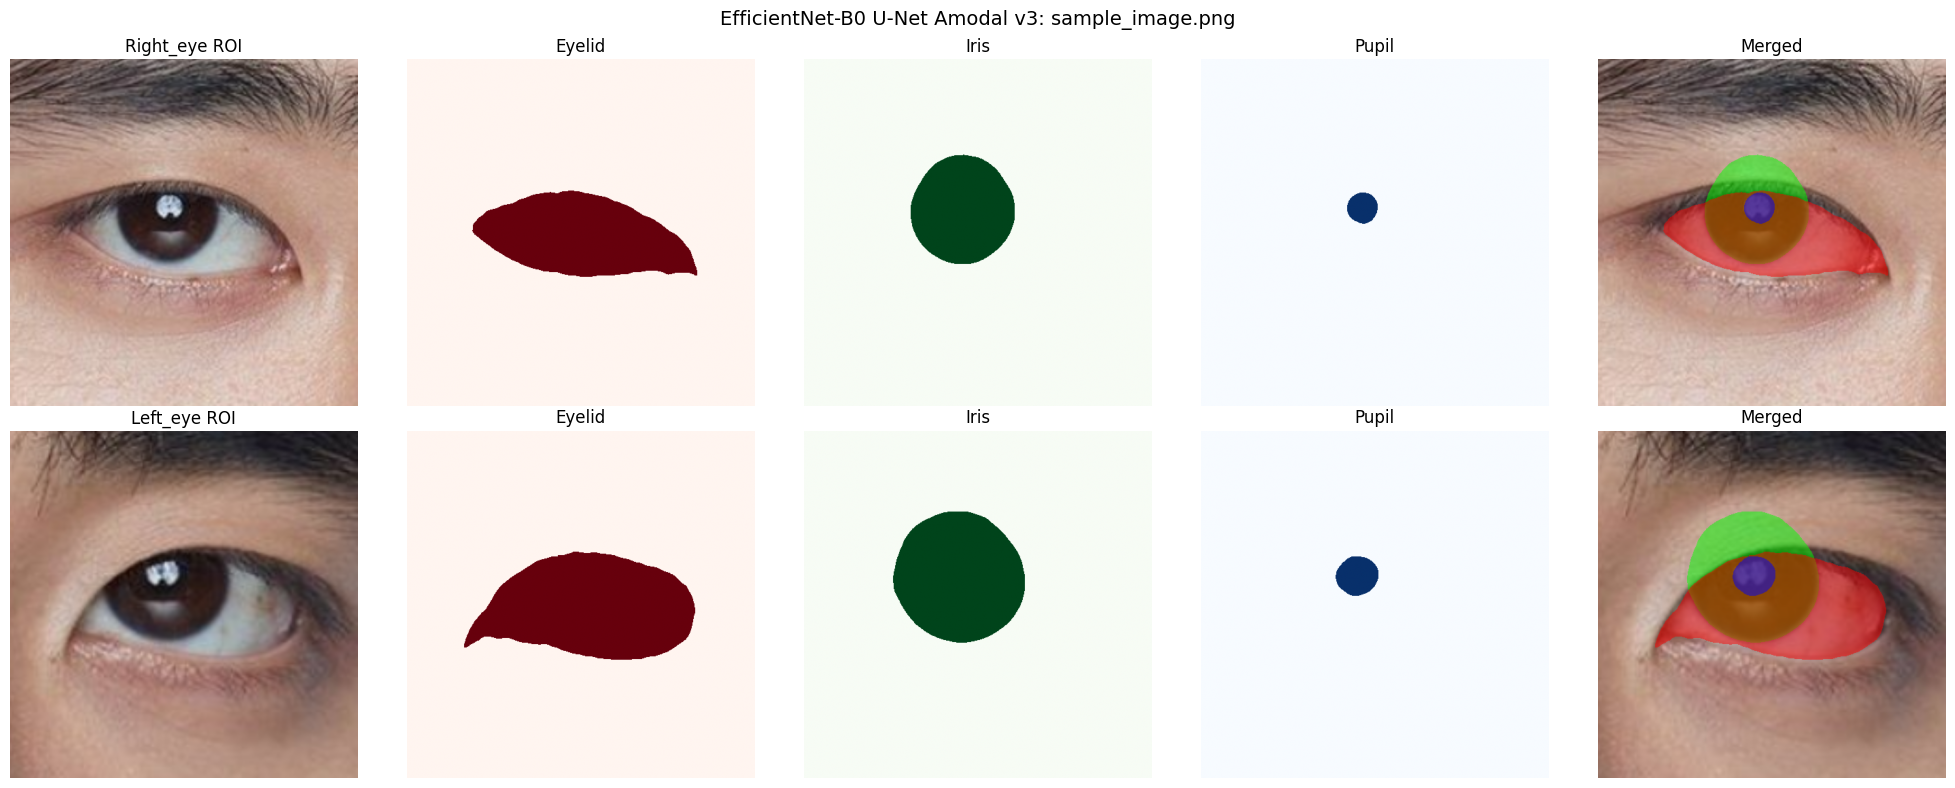


    sample_image_2.jpeg
Detected 2 eyes
  Left_eye: Eyelid=5.8%, Iris=8.0%, Pupil=0.3%
  Right_eye: Eyelid=5.9%, Iris=8.8%, Pupil=0.8%


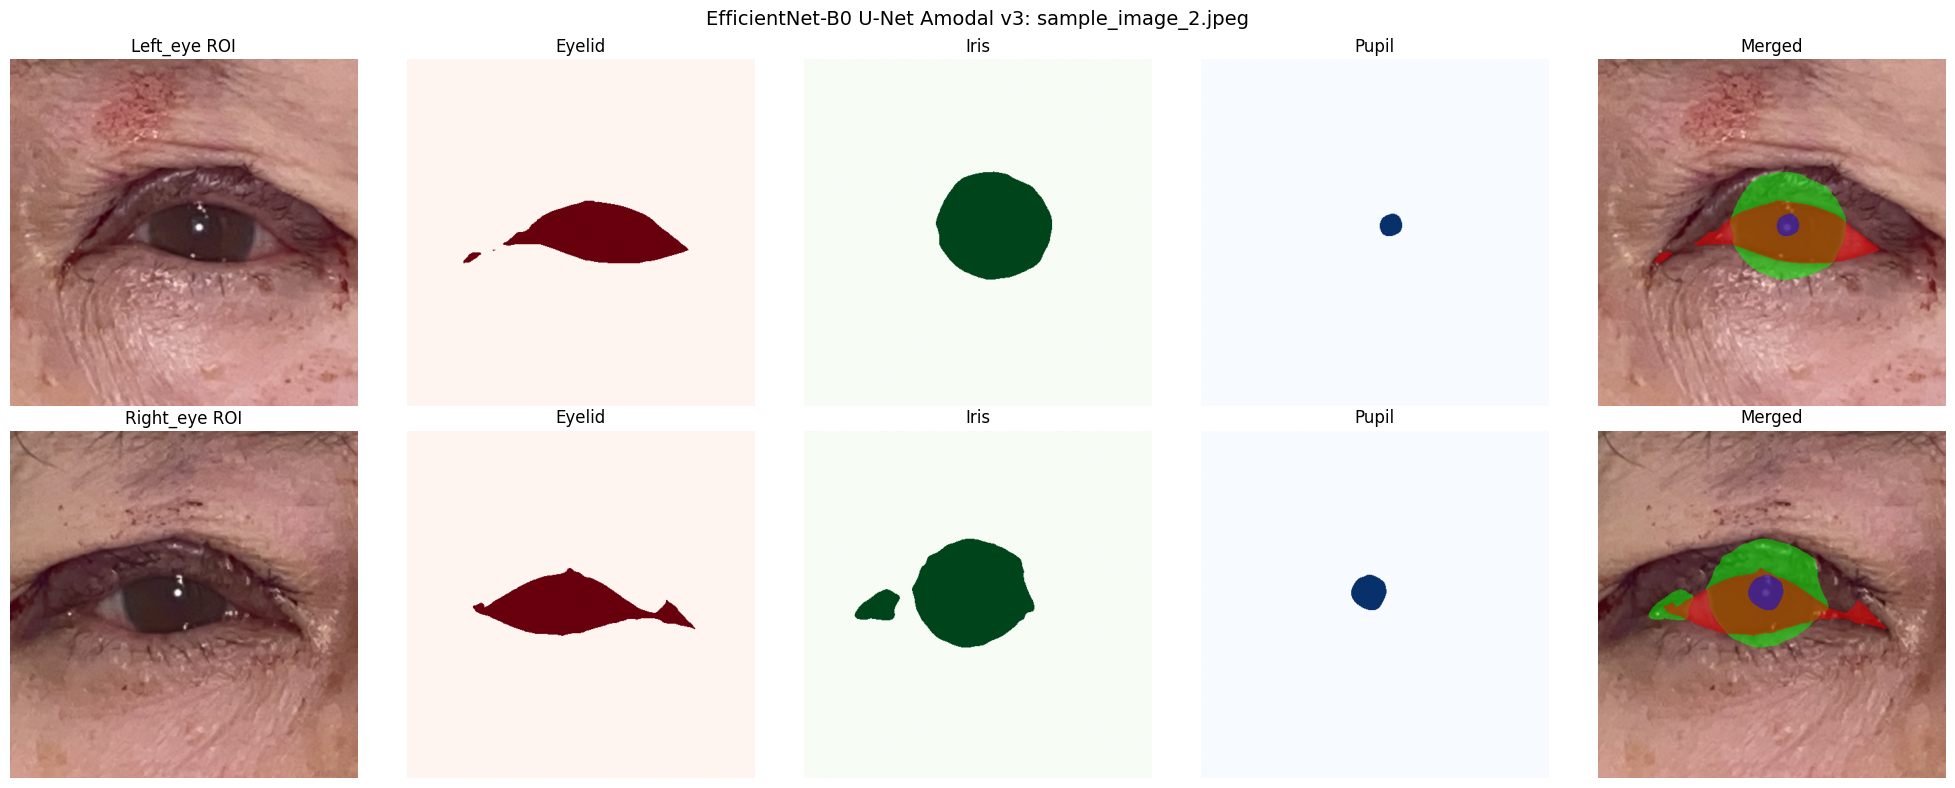

In [1]:
# ===== Cell 21: Real-World Inference Test =====
# Periocular領域検出＋学習したモデルでセグメンテーション推論を実行
# このセル単体でも実行可能

import sys
if 'cv2' not in sys.modules:
    import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
import segmentation_models_pytorch as smp
from ultralytics import YOLO

# === 設定 ===
PROJECT_ROOT = Path(".").resolve()
PERIOCULAR_DIR = PROJECT_ROOT / "Periocular_detection"
DETECT_MODEL_PATH = PERIOCULAR_DIR / "YOLO11l-detect.pt"
SAMPLE_IMAGES = [PERIOCULAR_DIR / "sample_image.png", PERIOCULAR_DIR / "sample_image_2.jpeg"]
ENCODER_NAME = "efficientnet-b0"
ENCODER_WEIGHTS = "imagenet"
IMAGE_SIZE, EXPANSION_RATIO = 512, 0.25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Helper Functions ===
def extract_roi(image, bbox, roi_size=512, expansion_ratio=0.25):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = bbox
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side = max(x2 - x1, y2 - y1) * (1 + 2 * expansion_ratio)
    nx1, ny1 = int(cx - side / 2), int(cy - side / 2)
    nx2, ny2 = int(cx + side / 2), int(cy + side / 2)
    pad_top, pad_bottom = max(0, -ny1), max(0, ny2 - h)
    pad_left, pad_right = max(0, -nx1), max(0, nx2 - w)
    roi = image[max(0, ny1):min(h, ny2), max(0, nx1):min(w, nx2)].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        roi = cv2.copyMakeBorder(roi, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=[0,0,0])
    return cv2.resize(roi, (roi_size, roi_size))

def predict_amodal_simple(seg_model, roi_rgb, device, image_size=512, threshold=0.5):
    normalize = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    pixel_values = normalize(roi_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = seg_model(pixel_values)  # smp returns (B, C, H, W) directly
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    return {name: ((probs[c] > threshold) * 255).astype(np.uint8) for c, name in enumerate(['eyelid', 'iris', 'pupil'])}

def create_overlay(img_rgb, masks, alpha_eyelid=0.5, alpha_iris=0.5, alpha_pupil=0.5):
    """Create overlay: eyelid=RED (濃い), iris=GREEN (薄い), pupil=BLUE"""
    h, w = img_rgb.shape[:2]
    result = img_rgb.copy().astype(np.float32)
    
    # Iris: 薄く（Eyelidの下に見えるように）
    iris_mask = masks['iris'] > 0
    if iris_mask.any():
        result[iris_mask] = result[iris_mask] * (1 - alpha_iris) + np.array([0, 255, 0]) * alpha_iris
    
    # Eyelid: 濃いめ（見やすく）
    eyelid_mask = masks['eyelid'] > 0
    if eyelid_mask.any():
        result[eyelid_mask] = result[eyelid_mask] * (1 - alpha_eyelid) + np.array([255, 0, 0]) * alpha_eyelid
    
    # Pupil: 通常
    pupil_mask = masks['pupil'] > 0
    if pupil_mask.any():
        result[pupil_mask] = result[pupil_mask] * (1 - alpha_pupil) + np.array([0, 0, 255]) * alpha_pupil
    
    return result.astype(np.uint8)

# === Load Models ===
print("Loading models...")
detect_model = YOLO(str(DETECT_MODEL_PATH))

# Load SegFormer model (use existing 'model' if available, otherwise load from checkpoint)
if 'model' not in dir() or model is None:
    MODEL_DIR = PROJECT_ROOT / "Ablation_EfficientNetB0_UNet_Amodal_Blur_v3" / "models"
    model_path = MODEL_DIR / "efficientnet_b0_unet_amodal_v3_best.pth"
    model = smp.Unet(encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS, in_channels=3, classes=3, activation=None).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    print(f"  Loaded EfficientNet-B0 U-Net from: {model_path.name}")
print(f"  YOLO classes: {detect_model.names}")

# === Run Pipeline ===
for img_path in SAMPLE_IMAGES:
    if not img_path.exists():
        print(f"Image not found: {img_path}")
        continue
    
    print(f"""
    {'='*50}
    {img_path.name}
    {'='*50}""")

    img = cv2.imread(str(img_path))
    detections = detect_model.predict(source=img, conf=0.25, iou=0.45, verbose=False)[0]
    print(f"Detected {len(detections.boxes)} eyes")
    
    if len(detections.boxes) == 0:
        continue
    
    results = []
    for box in detections.boxes:
        eye_name = detect_model.names[int(box.cls[0])]
        roi = extract_roi(img, box.xyxy[0].cpu().numpy(), IMAGE_SIZE, EXPANSION_RATIO)
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        masks = predict_amodal_simple(model, roi_rgb, device, IMAGE_SIZE)
        results.append({'name': eye_name, 'roi': roi_rgb, 'masks': masks})
        print(f"  {eye_name}: Eyelid={100*(masks['eyelid']>0).mean():.1f}%, Iris={100*(masks['iris']>0).mean():.1f}%, Pupil={100*(masks['pupil']>0).mean():.1f}%")
    
    n = len(results)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4*n))
    if n == 1: axes = axes.reshape(1, -1)
    for i, res in enumerate(results):
        axes[i,0].imshow(res['roi']); axes[i,0].set_title(f"{res['name']} ROI"); axes[i,0].axis('off')
        axes[i,1].imshow(res['masks']['eyelid'], cmap='Reds', vmin=0, vmax=255); axes[i,1].set_title('Eyelid'); axes[i,1].axis('off')
        axes[i,2].imshow(res['masks']['iris'], cmap='Greens', vmin=0, vmax=255); axes[i,2].set_title('Iris'); axes[i,2].axis('off')
        axes[i,3].imshow(res['masks']['pupil'], cmap='Blues', vmin=0, vmax=255); axes[i,3].set_title('Pupil'); axes[i,3].axis('off')
        axes[i,4].imshow(create_overlay(res['roi'], res['masks'])); axes[i,4].set_title('Merged'); axes[i,4].axis('off')
    plt.suptitle(f"EfficientNet-B0 U-Net Amodal v3: {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()